In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


# **Dataset**

In [2]:
import kagglehub
import os

# Download the latest version
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("Path to dataset files:", path)
print("Files and folders:", os.listdir(path))

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
Files and folders: ['Training', 'Testing']


In [26]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level

    print(indent + os.path.basename(root) + "/")

    if level < 2:
        for file in files[:5]:
            print(indent + "    " + file)

brain-tumor-mri-dataset/
    Training/
        pituitary/
        notumor/
        meningioma/
        glioma/
    Testing/
        pituitary/
        notumor/
        meningioma/
        glioma/


In [27]:
TRAIN_DIR = os.path.join(path, "Training")
TEST_DIR = os.path.join(path, "Testing")

print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

Training directory: /kaggle/input/brain-tumor-mri-dataset/Training
Testing directory: /kaggle/input/brain-tumor-mri-dataset/Testing


In [28]:
from torchvision import datasets

full_train_dataset = datasets.ImageFolder(TRAIN_DIR)
test_dataset = datasets.ImageFolder(TEST_DIR)

print("Classes:", full_train_dataset.classes)
print("Class mapping:", full_train_dataset.class_to_idx)
print("Training images:", len(full_train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training images: 5600
Testing images: 1600


# **Image Transformation**

In [29]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)


In [30]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# **Loading Dataset**

In [31]:
full_train_dataset = datasets.ImageFolder(TRAIN_DIR)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Classes:", full_train_dataset.classes)
print("Class mapping:", full_train_dataset.class_to_idx)
print("Training images:", len(full_train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training images: 5600
Testing images: 1600


# **Splitting Training Data**

In [32]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

In [33]:
train_dataset = copy.copy(train_subset)
val_dataset = copy.copy(val_subset)

train_dataset.dataset = copy.copy(full_train_dataset)
val_dataset.dataset = copy.copy(full_train_dataset)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 4480
Validation samples: 1120
Testing samples: 1600


# **Data Loader**

In [34]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [35]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels in batch:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels in batch: tensor([1, 3, 0, 0, 1, 3, 2, 1, 0, 2])


# **Loading ResNet 50**

In [36]:
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

print("ResNet50 loaded successfully")

ResNet50 loaded successfully


In [37]:
# Freeze all pretrained layers
for parameter in model.parameters():
    parameter.requires_grad = False

In [38]:
number_of_classes = len(full_train_dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    number_of_classes
)

In [39]:
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

In [40]:
model = model.to(device)

In [41]:
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print("Trainable:", name)

Trainable: layer4.0.conv1.weight
Trainable: layer4.0.bn1.weight
Trainable: layer4.0.bn1.bias
Trainable: layer4.0.conv2.weight
Trainable: layer4.0.bn2.weight
Trainable: layer4.0.bn2.bias
Trainable: layer4.0.conv3.weight
Trainable: layer4.0.bn3.weight
Trainable: layer4.0.bn3.bias
Trainable: layer4.0.downsample.0.weight
Trainable: layer4.0.downsample.1.weight
Trainable: layer4.0.downsample.1.bias
Trainable: layer4.1.conv1.weight
Trainable: layer4.1.bn1.weight
Trainable: layer4.1.bn1.bias
Trainable: layer4.1.conv2.weight
Trainable: layer4.1.bn2.weight
Trainable: layer4.1.bn2.bias
Trainable: layer4.1.conv3.weight
Trainable: layer4.1.bn3.weight
Trainable: layer4.1.bn3.bias
Trainable: layer4.2.conv1.weight
Trainable: layer4.2.bn1.weight
Trainable: layer4.2.bn1.bias
Trainable: layer4.2.conv2.weight
Trainable: layer4.2.bn2.weight
Trainable: layer4.2.bn2.bias
Trainable: layer4.2.conv3.weight
Trainable: layer4.2.bn3.weight
Trainable: layer4.2.bn3.bias
Trainable: fc.weight
Trainable: fc.bias


In [42]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

In [43]:
# Training Function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [44]:
# Testing Function
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probabilities = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.append(labels.cpu())
            all_probabilities.append(probabilities.cpu())

    average_loss = total_loss / total
    accuracy = correct / total

    all_labels = torch.cat(all_labels).numpy()
    all_probabilities = torch.cat(all_probabilities).numpy()

    return (
        average_loss,
        accuracy,
        all_labels,
        all_probabilities
    )

# **Model Training**

In [45]:
NUM_EPOCHS = 15

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_labels,
        val_probabilities
    ) = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": full_train_dataset.classes,
                "best_val_accuracy": best_val_accuracy
            },
            "/content/best_resnet50_brain_tumor.pth"
        )

        print("Best checkpoint saved.")

Epoch [1/15] | Train Loss: 1.2285 | Train Acc: 0.5971 | Val Loss: 1.0524 | Val Acc: 0.8214
Best checkpoint saved.
Epoch [2/15] | Train Loss: 0.7306 | Train Acc: 0.8359 | Val Loss: 0.6424 | Val Acc: 0.8634
Best checkpoint saved.
Epoch [3/15] | Train Loss: 0.4409 | Train Acc: 0.8672 | Val Loss: 0.4770 | Val Acc: 0.8795
Best checkpoint saved.
Epoch [4/15] | Train Loss: 0.3393 | Train Acc: 0.8868 | Val Loss: 0.4544 | Val Acc: 0.8875
Best checkpoint saved.
Epoch [5/15] | Train Loss: 0.2783 | Train Acc: 0.9065 | Val Loss: 0.2885 | Val Acc: 0.9089
Best checkpoint saved.
Epoch [6/15] | Train Loss: 0.2504 | Train Acc: 0.9167 | Val Loss: 0.4297 | Val Acc: 0.9071
Epoch [7/15] | Train Loss: 0.2138 | Train Acc: 0.9261 | Val Loss: 0.3442 | Val Acc: 0.9161
Best checkpoint saved.
Epoch [8/15] | Train Loss: 0.1866 | Train Acc: 0.9355 | Val Loss: 0.2168 | Val Acc: 0.9304
Best checkpoint saved.
Epoch [9/15] | Train Loss: 0.1795 | Train Acc: 0.9373 | Val Loss: 0.5951 | Val Acc: 0.9277
Epoch [10/15] | Trai

In [47]:
# Load the Best Model
checkpoint = torch.load(
    "/content/best_resnet50_brain_tumor.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Best validation accuracy:", checkpoint["best_val_accuracy"])

Best validation accuracy: 0.95


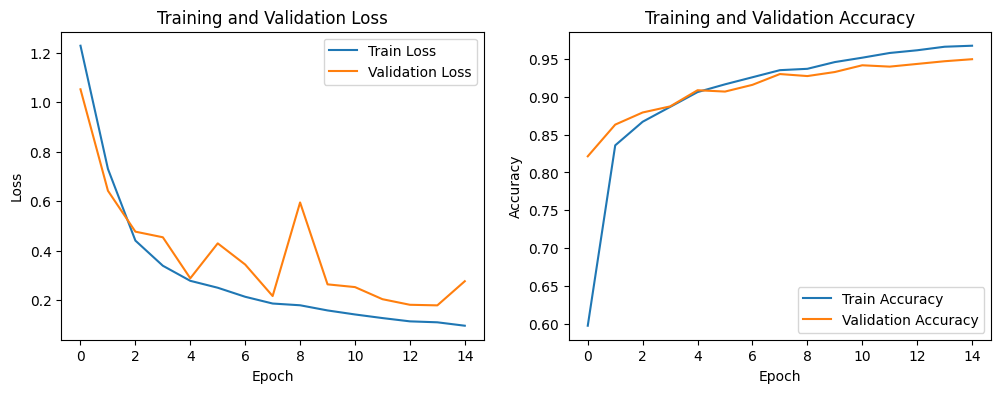

In [49]:
# Loss and Accuracy Graph
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

# **Evaluation on Testing Data**

In [50]:
test_loss, test_accuracy, test_labels, test_probabilities = (
    validate_one_epoch(
        model,
        test_loader,
        criterion,
        device
    )
)

test_predictions = test_probabilities.argmax(axis=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.5530
Test Accuracy: 0.9069


In [51]:
roc_auc = roc_auc_score(
    test_labels,
    test_probabilities,
    multi_class="ovr",
    average="macro"
)

pr_auc = average_precision_score(
    test_labels,
    test_probabilities,
    average="macro"
)

print(f"Multiclass ROC-AUC: {roc_auc:.4f}")
print(f"Macro PR-AUC: {pr_auc:.4f}")

Multiclass ROC-AUC: 0.9821
Macro PR-AUC: 0.9523


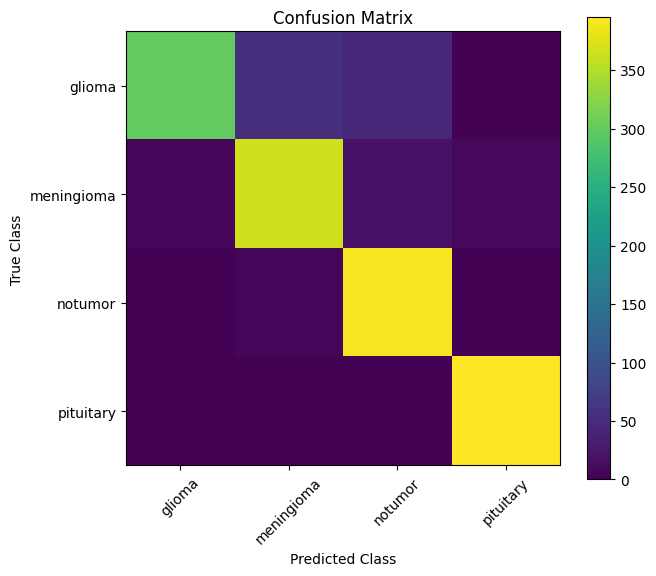

In [52]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()

plt.xticks(
    range(len(full_train_dataset.classes)),
    full_train_dataset.classes,
    rotation=45
)

plt.yticks(
    range(len(full_train_dataset.classes)),
    full_train_dataset.classes
)

plt.show()

# **Real Life Check**

In [53]:
def predict_mri(image_path, model, class_names, device):
    # Open image and convert it to RGB
    image = Image.open(image_path).convert("RGB")

    # Apply the same validation transformations used during testing
    image_tensor = val_test_transform(image)

    # Add batch dimension: [3, 224, 224] → [1, 3, 224, 224]
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Disable gradient calculation during prediction
    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)

        # Convert model outputs into probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Get the class with the highest probability
        predicted_index = probabilities.argmax(dim=1).item()

        predicted_class = class_names[predicted_index]
        confidence = probabilities[0][predicted_index].item()

    # Display the uploaded MRI
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.show()

    return predicted_class, confidence

In [59]:
from google.colab import files

uploaded = files.upload()

Saving 1.png to 1 (1).png


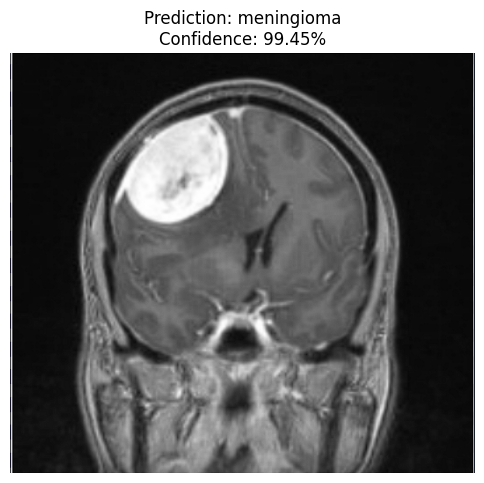

Predicted class: meningioma
Confidence: 99.45%


In [60]:
from PIL import Image
uploaded_file_name = next(iter(uploaded))

predicted_class, confidence = predict_mri(
    image_path=uploaded_file_name,
    model=model,
    class_names=full_train_dataset.classes,
    device=device
)

print("Predicted class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

In [61]:
if predicted_class == "notumor":
    print("Model result: No tumor category detected.")
else:
    print(f"Model result: {predicted_class} category detected.")

print(
    "\nImportant: This is an experimental AI prediction, "
    "not a medical diagnosis. Consult a qualified radiologist "
    "or doctor for clinical interpretation."
)

Model result: meningioma category detected.

Important: This is an experimental AI prediction, not a medical diagnosis. Consult a qualified radiologist or doctor for clinical interpretation.
